In [10]:
import cudf as cf
import cupy as cp

import optuna
# Use native XGBoost Dask API instead of dask-ml
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor

import plotly.express as px
from plotly.io import show

In [11]:
# Load the processed data
print("Loading csv data...")
df_with_encoding = cf.read_csv("./tmp/unfv_route_39_no_na_dropped_encoding.csv")
df_without_encoding = cf.read_csv("./tmp/df_39_no_na_dropped_without_encoding.csv")
print(f"Columns: {df_with_encoding.columns.tolist()}")

Loading csv data...
Columns: ['route', 'trip_id', 'stopid', 'actual_arrival', 'hour', 'day_of_week', 'month', 'day_of_year', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'delay_seconds', 'nearest_whole_hour', 'Climate ID', 'Temp (°C)', 'Dew Point Temp (°C)', 'Rel Hum (%)', 'Wind Spd (km/h)', 'Visibility (km)', 'Stn Press (kPa)', 'Precip. Amount (mm)', 'bound', 'thrustreet', 'thrusteet_Baldoon Rd', 'thrusteet_Crow Trail', 'thrusteet_Finch Ave East', 'thrusteet_Finch Ave East - St Aidan', 'thrusteet_Finch Ave West', 'thrusteet_Finch Station', 'thrusteet_Gordon Baker Rd', 'thrusteet_Harold Evans Cres', 'thrusteet_Littles Rd', 'thrusteet_McNicoll Ave', 'thrusteet_Morningview Trail', 'thrusteet_Neilson Rd', 'thrusteet_Old Finch Ave', 'thrusteet_Victoria Park Ave']


In [12]:
df_with_encoding.dtypes

route                                  float64
trip_id                                  int64
stopid                                   int64
actual_arrival                          object
hour                                     int64
day_of_week                              int64
month                                    int64
day_of_year                              int64
hour_sin                               float64
hour_cos                               float64
day_of_week_sin                        float64
day_of_week_cos                        float64
delay_seconds                          float64
nearest_whole_hour                      object
Climate ID                             float64
Temp (°C)                              float64
Dew Point Temp (°C)                    float64
Rel Hum (%)                            float64
Wind Spd (km/h)                        float64
Visibility (km)                        float64
Stn Press (kPa)                        float64
Precip. Amoun

In [13]:
df_with_encoding.isna().sum()

route                                  0
trip_id                                0
stopid                                 0
actual_arrival                         0
hour                                   0
day_of_week                            0
month                                  0
day_of_year                            0
hour_sin                               0
hour_cos                               0
day_of_week_sin                        0
day_of_week_cos                        0
delay_seconds                          0
nearest_whole_hour                     0
Climate ID                             0
Temp (°C)                              0
Dew Point Temp (°C)                    0
Rel Hum (%)                            0
Wind Spd (km/h)                        0
Visibility (km)                        0
Stn Press (kPa)                        0
Precip. Amount (mm)                    0
bound                                  0
thrustreet                             0
thrusteet_Baldoo

In [14]:
df_with_encoding['delay_seconds'].describe()

count    2.153208e+06
mean     2.098825e+02
std      1.118733e+03
min      1.000000e-03
25%      4.200000e+01
50%      9.900000e+01
75%      2.058070e+02
max      3.644455e+04
Name: delay_seconds, dtype: float64


## EDA

Correlation Analysis of dataset with categorical column

In [15]:
## correlation analysis of features with the target variable and show it in table
# remove thrusteet
df_corr_encoded_data = df_with_encoding.drop(columns=['thrustreet', 'route', 'trip_id', 'Climate ID', 'actual_arrival', 'nearest_whole_hour']).to_pandas()  # Convert to pandas for correlation analysis
correlation_matrix = df_corr_encoded_data.corr(method='pearson')
target_correlation = correlation_matrix['delay_seconds'].drop('delay_seconds')  
print("Correlation of features with delay_seconds:")
print(target_correlation.sort_values(ascending=False))
# Visualize the correlation of features with the target variable using a bar chart
correlation_df = target_correlation.reset_index()
correlation_df.columns = ['Correlation', 'Feature']
fig = px.bar(correlation_df, x='Feature', y='Correlation', title='Correlation of Features with delay_seconds')
show(fig)

Correlation of features with delay_seconds:
hour_sin                               0.060140
day_of_week_sin                        0.041569
day_of_year                            0.036378
month                                  0.033656
hour_cos                               0.029560
Rel Hum (%)                            0.015310
bound                                  0.013016
thrusteet_Victoria Park Ave            0.011527
thrusteet_Morningview Trail            0.009732
thrusteet_Neilson Rd                   0.009444
Wind Spd (km/h)                        0.007411
Visibility (km)                        0.006500
thrusteet_Finch Station                0.005100
thrusteet_Gordon Baker Rd              0.002600
thrusteet_McNicoll Ave                 0.001037
thrusteet_Finch Ave West               0.000553
thrusteet_Finch Ave East - St Aidan    0.000226
thrusteet_Harold Evans Cres           -0.000367
thrusteet_Finch Ave East              -0.001533
thrusteet_Littles Rd                  -0.003

Correlation Analysis of dataset without categorical column

In [16]:
## correlation analysis of features with the target variable and show it in table
# remove thrusteet
df_corr_without_encoding = df_without_encoding.drop(columns=['thrusteet', 'route', 'trip_id', 'Climate ID', 'actual_arrival', 'nearest_whole_hour']).to_pandas()  # Convert to pandas for correlation analysis
correlation_matrix = df_corr_without_encoding.corr(method='pearson')
target_correlation = correlation_matrix['delay_seconds'].drop('delay_seconds')  
print("Correlation of features with delay_seconds:")
print(target_correlation.sort_values(ascending=False))
# Visualize the correlation of features with the target variable using a bar chart
correlation_df = target_correlation.reset_index()
correlation_df.columns = ['Correlation', 'Feature']
fig = px.bar(correlation_df, x='Feature', y='Correlation', title='Correlation of Features with delay_seconds')
show(fig)

Correlation of features with delay_seconds:
hour_sin               0.060140
day_of_week_sin        0.041569
day_of_year            0.036378
month                  0.033656
hour_cos               0.029560
Rel Hum (%)            0.015310
bound                  0.013016
Wind Spd (km/h)        0.007411
Visibility (km)        0.006500
Dew Point Temp (°C)   -0.003403
stopid                -0.004269
Precip. Amount (mm)   -0.004352
Temp (°C)             -0.009704
day_of_week           -0.009705
Stn Press (kPa)       -0.030960
hour                  -0.033102
day_of_week_cos       -0.034199
Name: delay_seconds, dtype: float64


VIF (Variance Inflation Factor) (categorical column included)

In [17]:
# calculate variance inflation factor (VIF) for each feature to check for multicollinearity
features = df_corr_encoded_data.drop(columns=['delay_seconds']).columns
vif_data = cf.DataFrame()
vif_data['Feature'] = features
vif_data['VIF'] = [variance_inflation_factor(df_corr_encoded_data[features].values, i) for i in range(len(features))]
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:
                                Feature          VIF
19             thrusteet_Finch Ave East  5555.328087
9                             Temp (°C)   242.766138
10                  Dew Point Temp (°C)   224.122464
29              thrusteet_Old Finch Ave   216.438537
4                           day_of_year   143.192827
3                                 month   143.038796
28                 thrusteet_Neilson Rd   104.091790
25                 thrusteet_Littles Rd    98.786397
18                 thrusteet_Crow Trail    88.139481
22              thrusteet_Finch Station    69.653401
30          thrusteet_Victoria Park Ave    64.830053
17                 thrusteet_Baldoon Rd    55.106492
27          thrusteet_Morningview Trail    50.244497
23            thrusteet_Gordon Baker Rd    48.580478
11                          Rel Hum (%)    33.043258
20  thrusteet_Finch Ave East - St Aidan    30.422964
24          thrusteet_Harold Evans Cres    14.083

VIF (categorical column excluded)

In [18]:
# calculate variance inflation factor (VIF) for each feature to check for multicollinearity
features = df_corr_without_encoding.drop(columns=['delay_seconds']).columns
vif_data = cf.DataFrame()
vif_data['Feature'] = features
vif_data['VIF'] = [variance_inflation_factor(df_corr_without_encoding[features].values, i) for i in range(len(features))]
print("Variance Inflation Factor (VIF) for each feature:")
print(vif_data.sort_values(by='VIF', ascending=False))

Variance Inflation Factor (VIF) for each feature:
                Feature          VIF
14      Stn Press (kPa)  1241.228559
3                 month   700.658219
4           day_of_year   618.036354
11          Rel Hum (%)   595.410133
9             Temp (°C)   411.983126
10  Dew Point Temp (°C)   244.066934
13      Visibility (km)    30.076232
2           day_of_week    10.152097
1                  hour     9.734580
12      Wind Spd (km/h)     4.727423
5              hour_sin     2.870470
7       day_of_week_sin     2.649191
0                stopid     2.119319
8       day_of_week_cos     1.414534
6              hour_cos     1.384490
15  Precip. Amount (mm)     1.098047
16                bound     1.027453


Shapiro-Wilk test

In [19]:
# do shapiro wilk test for normality of the target variable
stat, p = shapiro(df_with_encoding['delay_seconds'].to_pandas())
print(f"Shapiro-Wilk Test: Statistics={stat}, p-value={p}")
if p > 0.05:
    print("The target variable is normally distributed (fail to reject H0)")
else:
    print("The target variable is not normally distributed (reject H0)")

Shapiro-Wilk Test: Statistics=0.07941814397136171, p-value=1.604268010235658e-244
The target variable is not normally distributed (reject H0)


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:592: UserWarning:

scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 2153208.



In [20]:
df_with_encoding.head()

,route,trip_id,stopid,actual_arrival,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,...,thrusteet_Finch Ave West,thrusteet_Finch Station,thrusteet_Gordon Baker Rd,thrusteet_Harold Evans Cres,thrusteet_Littles Rd,thrusteet_McNicoll Ave,thrusteet_Morningview Trail,thrusteet_Neilson Rd,thrusteet_Old Finch Ave,thrusteet_Victoria Park Ave
0,39.0,76911080,8878,2025-01-01 00:07:14.000,0,2,1,1,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,39.0,76911080,8258,2025-01-01 00:07:29.928,0,2,1,1,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
2,39.0,76911080,10060,2025-01-01 00:07:48.000,0,2,1,1,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,39.0,97485080,938,2025-01-01 00:14:20.169,0,2,1,1,0.0,1.0,...,0,0,0,0,0,0,0,1,0,0
4,39.0,112467080,8878,2025-01-01 00:14:25.000,0,2,1,1,0.0,1.0,...,0,0,0,0,0,0,0,0,0,0


### Top 10 stop id with highest delay

In [21]:
# get top stopid with highest positive delay incidents
stopid_counts = df_with_encoding.groupby('stopid').size().reset_index(name='Count')
stopid_counts = stopid_counts.sort_values('Count', ascending=False)
top_routes = stopid_counts.head(10)
top_routes.stopid = top_routes.stopid.astype(str)  # Convert stopid to string for better visualization

fig = px.bar(top_routes, x='stopid', y='Count', title='Top 10 Stops with Highest positive delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='stopid', yaxis_title='Count')

fig.show()

### Delay by thrustreet

In [22]:
# delay by thrustreet > 0 delay seconds
thrustreet_counts = df_with_encoding.groupby('thrustreet').size().reset_index(name='Count')
thrustreet_counts = thrustreet_counts.sort_values('Count', ascending=False)
top_thrustreets = thrustreet_counts.head(5)
top_thrustreets.thrustreet = top_thrustreets.thrustreet.astype(str
)  # Convert thrustreet to string for better visualization
fig = px.bar(top_thrustreets, x='thrustreet', y='Count', title='Top 5 Thrustreets with Highest positive delay incidents',
             color='Count', color_continuous_scale='viridis')
fig.update_layout(xaxis_title='thrustreet', yaxis_title='Count')
fig.show()


### Delay by hour

In [23]:
# delay by hour with > 0 delay seconds
hour_counts = df_with_encoding['hour'].value_counts().sort_index()
hour_data = cf.DataFrame({'Hour': hour_counts.index, 'Count': hour_counts.values})
fig = px.bar(hour_data, x='Hour', y='Count', title='Delay Incidents by Hour of the Day', color='Hour')
fig.update_layout(xaxis_title='Hour of the Day', yaxis_title='Count')
fig.show()

### Delay by week

In [24]:
# delay by week with > 0 delay seconds
day_counts = df_with_encoding['day_of_week'].value_counts().sort_index()
day_order = ['Sunday', 'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
day_data = cf.DataFrame({'Day of the Week': day_order, 'Count': day_counts})

fig = px.bar(day_data, x='Day of the Week', y='Count', title='Delay Incidents by Day of the Week', color='Day of the Week')
fig.update_layout(xaxis_title='Day of the Week', yaxis_title='Count')

fig.show()

### Delay by month

In [25]:
# delay by month with > 0 delay seconds
month_counts = df_with_encoding['month'].value_counts().sort_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

month_data = cf.DataFrame({'Month': month_order, 'Count': month_counts})

fig = px.pie(month_data, values='Count', names='Month', title='Frequency of Delays by Month',
             hole=0.4, color_discrete_sequence=px.colors.qualitative.Set2)
fig.update_traces(textinfo='percent+label', pull=[0.1, 0, 0, 0, 0, 0])

fig.show()

In [26]:
print(f"\nFeature shape(Dropped): {df_with_encoding.shape[0]:,} rows x {df_with_encoding.shape[1]} columns")


Feature shape(Dropped): 2,153,208 rows x 38 columns


## Model with encoded categorical data

### Simple Model

In [27]:
cp.get_default_memory_pool().free_all_blocks()

In [28]:
df_encoded_X = df_with_encoding.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrustreet', 'actual_arrival', 'nearest_whole_hour'])
df_encoded_y = df_with_encoding['delay_seconds']

In [29]:
X_train_encoded, X_test_encoded, y_train_encoded, y_test_encoded = train_test_split(
    df_encoded_X,
    df_encoded_y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_encoded):,}")
print(f"Test size: {len(X_test_encoded):,}")


Train size: 1,722,566
Test size: 430,642


In [30]:
X_train_encoded_cupy = X_train_encoded.to_cupy()
y_train_encoded_cupy = y_train_encoded.to_cupy()
X_test_encoded_cupy = X_test_encoded.to_cupy()
y_test_encoded_cupy = y_test_encoded.to_cupy()

In [31]:
# # Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,20_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_encoded_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_squares = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_encoded_cupy[train_index], label=y_train_encoded_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_encoded_cupy[val_index], label=y_train_encoded_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for R2 score calculation
        y_fold = y_train_encoded_cupy[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_squares[i] = r2_square

    # Return average R2 square across folds
    return float(np.mean(avg_r2_squares))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [32]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study
study_simple_encoded = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_simple_encoded.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_simple_encoded.best_trial.number}")
print(f"Best RMSE: {study_simple_encoded.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_simple_encoded.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 19:29:31,795] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:29:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:29:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:29:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:29:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:29:33,123] Trial 0 finished with value: 0.9308941352652914 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 18000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.9308941352652914.


...

[I 2026-03-22 19:30:39,649] Trial 47 finished with value: 0.8819678944463586 and parameters: {'max_depth': 10, 'learning_rate': 0.12294014799169678, 'n_estimators': 10000, 'subsample': 0.9627605614971158, 'colsample_bytree': 0.8681457933685772}. Best is trial 17 with value: 0.9527712777769806.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:40] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:30:41,533] Trial 48 finished with value: 0.9198414712188514 and parameters: {'max_depth': 10, 'learning_rate': 0.1553868062228685, 'n_estimators': 10000, 'subsample': 0.923971050710201, 'colsample_bytree': 0.8920229797513524}. Best is trial 17 with value: 0.9527712777769806.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:30:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:30:43,050] Trial 49 finished with value: 0.7677708348850152 and parameters: {'max_depth': 9, 'learning_rate': 0.08279284375665742, 'n_estimators': 12000, 'subsample': 0.952435768983924, 'colsample_bytree': 0.7641376909429222}. Best is trial 17 with value: 0.9527712777769806.

OPTIMIZATION COMPLETE!

Best trial: #17
Best RMSE: 0.9528

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.28668645969289
  n_estimators: 16000
  subsample: 0.7684757213625769
  colsample_bytree: 0.6516819941479122


In [33]:
fig = optuna.visualization.plot_param_importances(study_simple_encoded)
show(fig)

In [34]:
study_simple_encoded.best_params

{'max_depth': 10,
 'learning_rate': 0.28668645969289,
 'n_estimators': 16000,
 'subsample': 0.7684757213625769,
 'colsample_bytree': 0.6516819941479122}

In [35]:
cp.get_default_memory_pool().free_all_blocks()

In [36]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_simple = study_simple_encoded.best_params.copy()
best_params_clean = {k: v for k, v in best_params_simple.items() if k != 'num_boost_round'}
best_params_simple['objective'] = 'reg:squarederror'
best_params_simple['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_encoded_cupy, y_train_encoded_cupy)

# Train final model using native Dask XGBoost
output_simple_encoded = xgb.train(
    best_params_simple,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[19:30:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [37]:
dtest = xgb.DMatrix(X_test_encoded_cupy)
y_pred_dropped = output_simple_encoded.predict(dtest)

In [38]:
rmse_simple_encoded = np.sqrt(mean_squared_error(y_test_encoded_cupy.get(), y_pred_dropped))
r2_simple_encoded = r2_score(y_test_encoded_cupy.get(), y_pred_dropped)
mae_simple_encoded = mean_absolute_error(y_test_encoded_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_simple_encoded:.4f}")
print(f"  R²: {r2_simple_encoded:.4f}")
print(f"  MAE: {mae_simple_encoded:.4f}")

Final Model Performance on Test Set:
  RMSE: 235.6671
  R²: 0.9538
  MAE: 123.3959


In [47]:
import pandas as pd
map_with_features = output_simple_encoded.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_encoded_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
print(feature_importance_df)

                                Feature          Gain
8                       day_of_week_cos  2.049470e+09
11                          Rel Hum (%)  1.321871e+09
10                  Dew Point Temp (°C)  1.249245e+09
6                              hour_cos  1.111528e+09
12                      Wind Spd (km/h)  7.874268e+08
2                           day_of_week  5.987209e+08
9                             Temp (°C)  5.727928e+08
7                       day_of_week_sin  5.692180e+08
4                           day_of_year  3.586761e+08
3                                 month  3.260626e+08
1                                  hour  1.419124e+08
5                              hour_sin  9.180462e+07
14                      Stn Press (kPa)  2.925617e+07
13                      Visibility (km)  8.930983e+06
21              thrusteet_Finch Station  5.603822e+06
0                                stopid  4.722974e+06
26          thrusteet_Morningview Trail  4.703872e+06
16                          

In [48]:
output_simple_encoded.set_param({'device': 'cuda'})

In [49]:
import shap
shap_values = output_simple_encoded.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_simple_encoded)
shap_values = explainer.shap_values(X_test_encoded_cupy)
feature_names = df_encoded_X.columns.tolist()

In [50]:
shap_values

array([[ 9.8854589e+00, -4.5160246e-01,  1.2153484e+00, ...,
        -4.1532871e-01, -2.7846441e-01, -6.5005079e-02],
       [-4.8072157e+00,  8.6612787e+00, -6.2001090e+00, ...,
        -1.0892465e+00,  4.9916409e-02, -1.0842292e-01],
       [ 9.5203848e+00, -8.4319293e+02, -4.8866840e+02, ...,
         2.3568197e-01, -5.3014480e-02, -3.9797094e-02],
       ...,
       [ 3.8845749e+00,  8.5643616e+00,  2.5122395e+00, ...,
        -2.8772208e-01,  1.0295674e+00, -7.1378209e-02],
       [-9.4354811e+00,  2.5831394e+00, -2.6204989e+00, ...,
        -9.1056919e-01, -3.6491188e-01, -1.8200083e-01],
       [ 1.6946226e+01, -6.2406898e+00,  3.1584578e+00, ...,
        -5.2406245e-01, -4.6938151e-02, -5.3220332e-02]],
      shape=(430642, 32), dtype=float32)

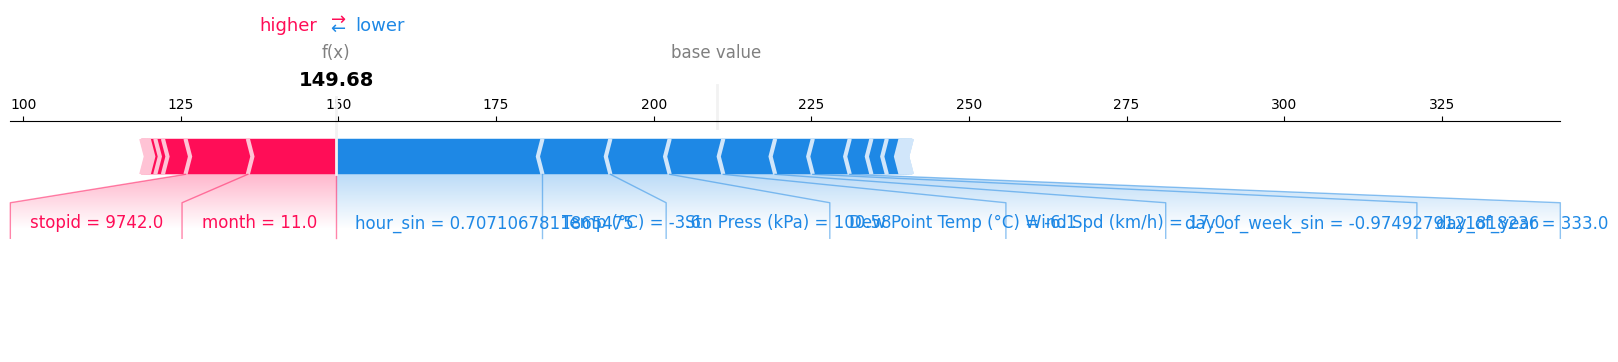

In [51]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_encoded_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

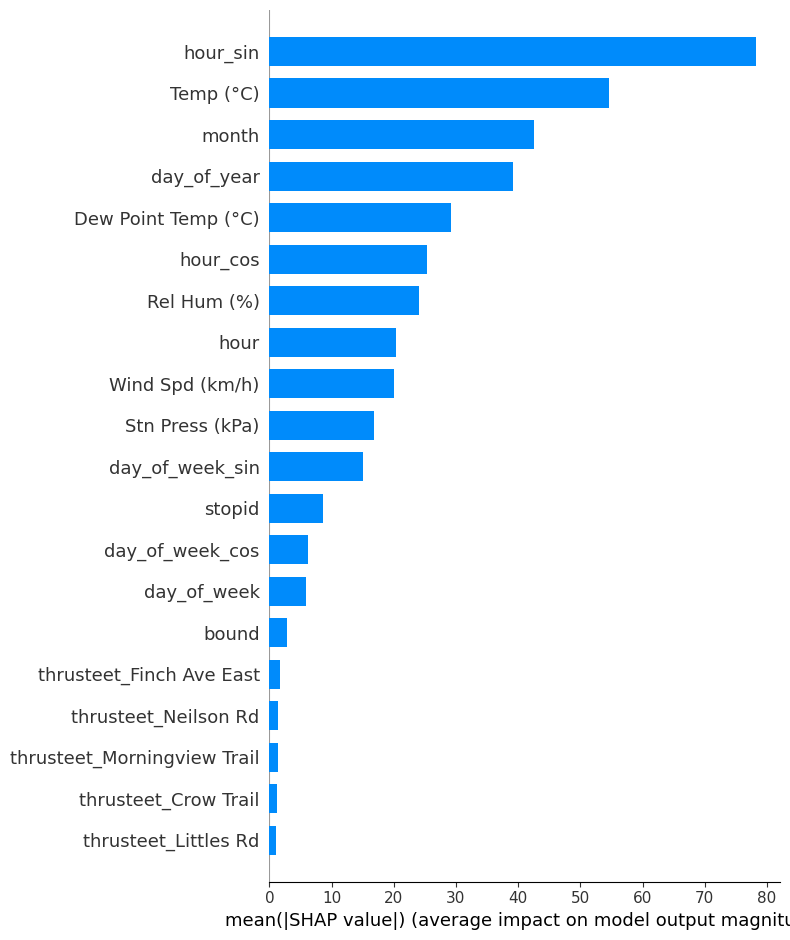

In [52]:
shap.summary_plot(shap_values, X_test_encoded_cupy, plot_type="bar", feature_names=feature_names)

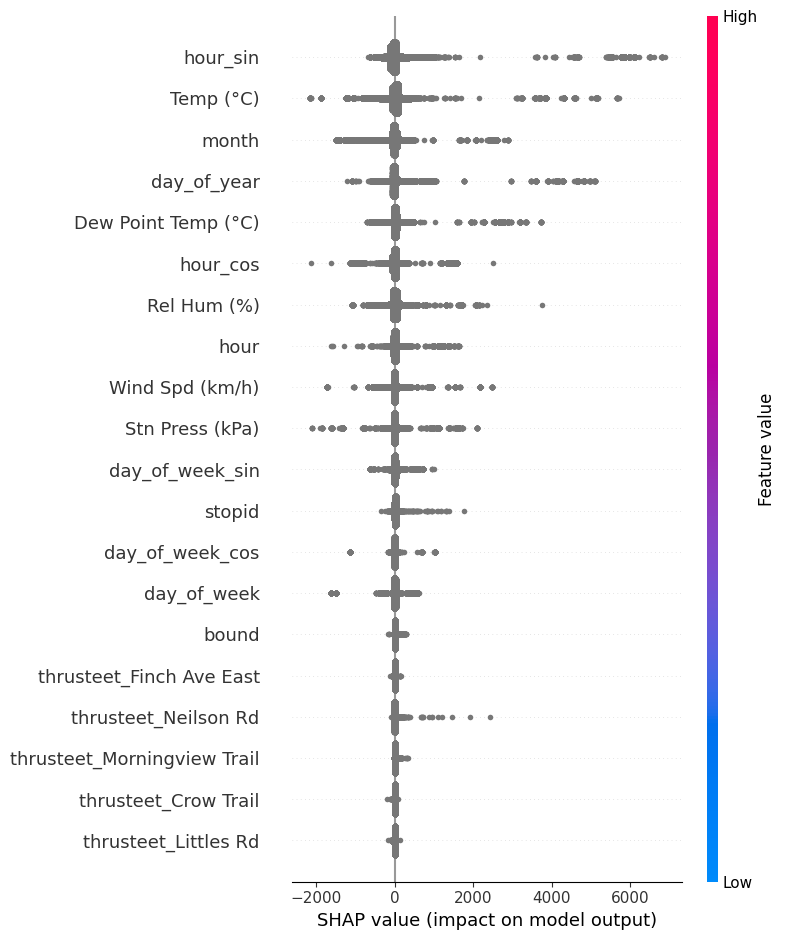

In [53]:
shap.summary_plot(shap_values, X_test_encoded_cupy, feature_names=feature_names)

### Complex Model

In [54]:
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_encoded_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_encoded_cupy[train_index], label=y_train_encoded_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_encoded_cupy[val_index], label=y_train_encoded_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_encoded_cupy[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [55]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study with optuna
study_complex_encoded = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_complex_encoded.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_complex_encoded.best_trial.number}")
print(f"Best RMSE: {study_complex_encoded.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_complex_encoded.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 19:33:02,971] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:33:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:33:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:33:03] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:33:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:33:04,953] Trial 0 finished with value: 0.9019310463619148 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.9019310463619148.


...

[I 2026-03-22 19:34:04,284] Trial 47 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:04] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:34:06,168] Trial 48 finished with value: 0.9362680254803056 and parameters: {'max_leaves': 247, 'learning_rate': 0.2532433493275618, 'n_estimators': 11000, 'subsample': 0.9088478949836266, 'colsample_bytree': 0.9595999531846413, 'reg_lambda': 0.010104307429595904, 'reg_alpha': 0.47495006520962174, 'gamma': 2.5716969476749334, 'min_child_weight': 24, 'colsample_bylevel': 0.6610535421990057, 'colsample_bynode': 0.741331913278461}. Best is trial 13 with value: 0.9426374825228304.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:06] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-22 19:34:06,580] Trial 49 pruned. 

OPTIMIZATION COMPLETE!

Best trial: #13
Best RMSE: 0.9426

Best hyperparameters:
  max_leaves: 390
  learning_rate: 0.2967167397369285
  n_estimators: 14000
  subsample: 0.829622251163304
  colsample_bytree: 0.9861351784261821
  reg_lambda: 0.5155007102178591
  reg_alpha: 0.5529376166246607
  gamma: 1.1382002833423974
  min_child_weight: 8
  colsample_bylevel: 0.7299820798583574
  colsample_bynode: 0.6852173781514894


In [57]:
fig = optuna.visualization.plot_param_importances(study_complex_encoded)
show(fig)

In [58]:
study_complex_encoded.best_params

{'max_leaves': 390,
 'learning_rate': 0.2967167397369285,
 'n_estimators': 14000,
 'subsample': 0.829622251163304,
 'colsample_bytree': 0.9861351784261821,
 'reg_lambda': 0.5155007102178591,
 'reg_alpha': 0.5529376166246607,
 'gamma': 1.1382002833423974,
 'min_child_weight': 8,
 'colsample_bylevel': 0.7299820798583574,
 'colsample_bynode': 0.6852173781514894}

In [59]:
cp.get_default_memory_pool().free_all_blocks()

In [60]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_complex = study_complex_encoded.best_params.copy()
best_params_clean = {k: v for k, v in best_params_complex.items() if k != 'num_boost_round'}
best_params_complex['objective'] = 'reg:squarederror'
best_params_complex['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_encoded_cupy, y_train_encoded_cupy)

# Train final model using native Dask XGBoost
output_complex_encoded = xgb.train(
    best_params_complex,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[19:34:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [61]:
dtest = xgb.DMatrix(X_test_encoded_cupy)
y_pred_dropped = output_complex_encoded.predict(dtest)

In [62]:
rmse_complex_encoded = np.sqrt(mean_squared_error(y_test_encoded_cupy.get(), y_pred_dropped))
r2_complex_encoded = r2_score(y_test_encoded_cupy.get(), y_pred_dropped)
mae_complex_encoded = mean_absolute_error(y_test_encoded_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_complex_encoded:.4f}")
print(f"  R²: {r2_complex_encoded:.4f}")
print(f"  MAE: {mae_complex_encoded:.4f}")

Final Model Performance on Test Set:
  RMSE: 287.1570
  R²: 0.9314
  MAE: 135.3649


In [63]:
import pandas as pd
map_with_features = output_complex_encoded.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_encoded_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
print(feature_importance_df)

                        Feature          Gain
10          Dew Point Temp (°C)  1.738762e+10
5                      hour_sin  1.537316e+10
11                  Rel Hum (%)  1.332324e+10
4                   day_of_year  8.127251e+09
12              Wind Spd (km/h)  7.205677e+09
7               day_of_week_sin  4.647664e+09
9                     Temp (°C)  4.285407e+09
3                         month  3.226644e+09
1                          hour  3.152002e+09
14              Stn Press (kPa)  1.146582e+09
6                      hour_cos  6.344423e+08
8               day_of_week_cos  2.745307e+08
2                   day_of_week  2.549089e+08
15          Precip. Amount (mm)  5.960361e+07
13              Visibility (km)  4.447400e+07
20      thrusteet_Finch Station  4.330567e+07
17         thrusteet_Baldoon Rd  4.121952e+07
16                        bound  3.819335e+07
23         thrusteet_Neilson Rd  3.477262e+07
18         thrusteet_Crow Trail  3.432186e+07
22  thrusteet_Morningview Trail  3

In [64]:
output_complex_encoded.set_param({'device': 'cuda'})

In [65]:
shap_values = output_complex_encoded.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_complex_encoded)
shap_values = explainer.shap_values(X_test_encoded_cupy)
feature_names = df_encoded_X.columns.tolist()

In [66]:
shap_values

array([[ 2.62539434e+00,  3.12246382e-01, -2.52513433e+00, ...,
        -8.42875302e-01,  7.25763291e-02,  0.00000000e+00],
       [-3.85768747e+00,  2.08899288e+01,  8.67877007e+00, ...,
        -6.27095759e-01,  1.20189376e-01,  0.00000000e+00],
       [ 6.56809378e+00, -8.11730194e+01, -5.66184807e+01, ...,
        -5.95250249e-01,  1.20189376e-01,  0.00000000e+00],
       ...,
       [ 6.24976218e-01,  8.53493690e+00, -8.42255402e+00, ...,
        -8.02668810e-01,  8.46676528e-01,  0.00000000e+00],
       [-1.93206501e+00, -1.13351345e+00,  1.11580503e+00, ...,
        -6.28956199e-01,  7.51790628e-02,  0.00000000e+00],
       [-2.89057040e+00, -7.94544744e+00,  1.79541659e+00, ...,
        -1.06645060e+00, -5.60866058e-01,  0.00000000e+00]],
      shape=(430642, 32), dtype=float32)

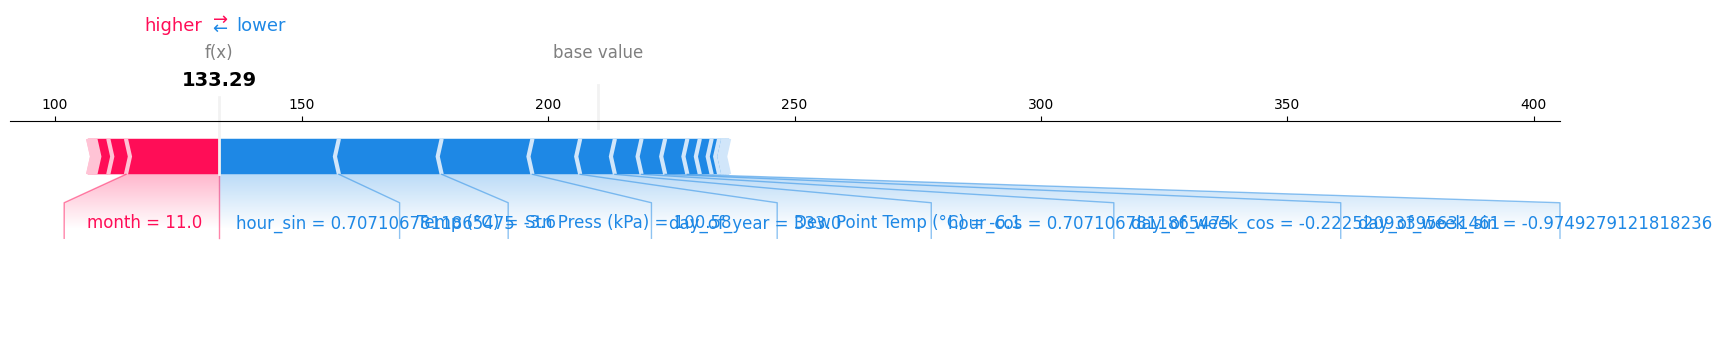

In [67]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_encoded_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

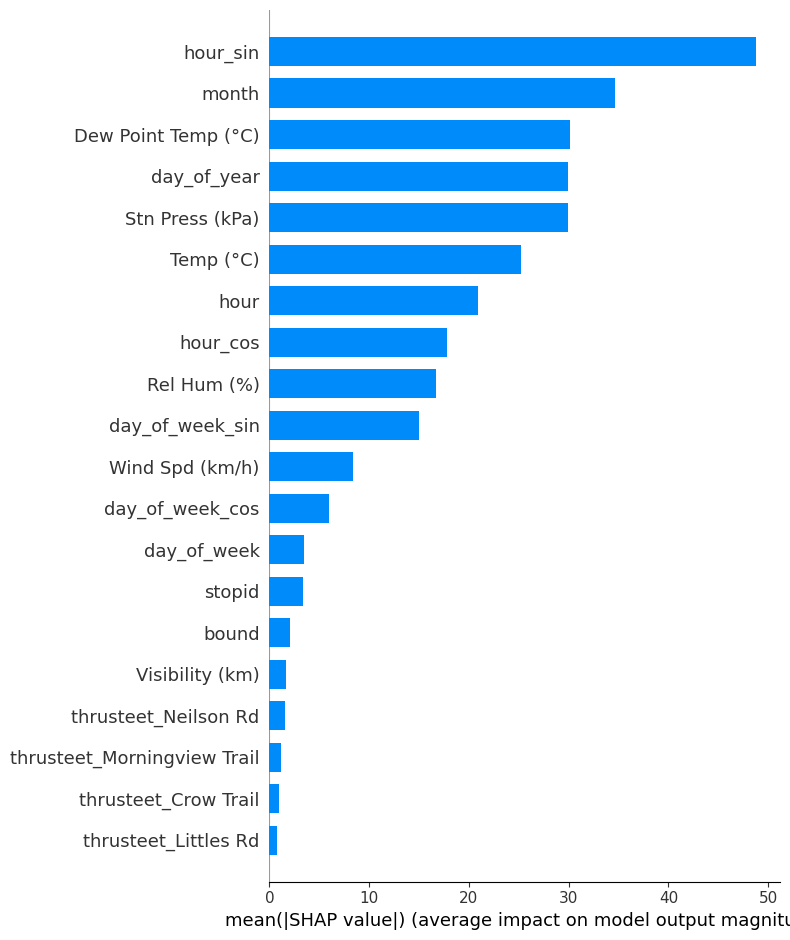

In [68]:
shap.summary_plot(shap_values, X_test_encoded_cupy, plot_type="bar", feature_names=feature_names)

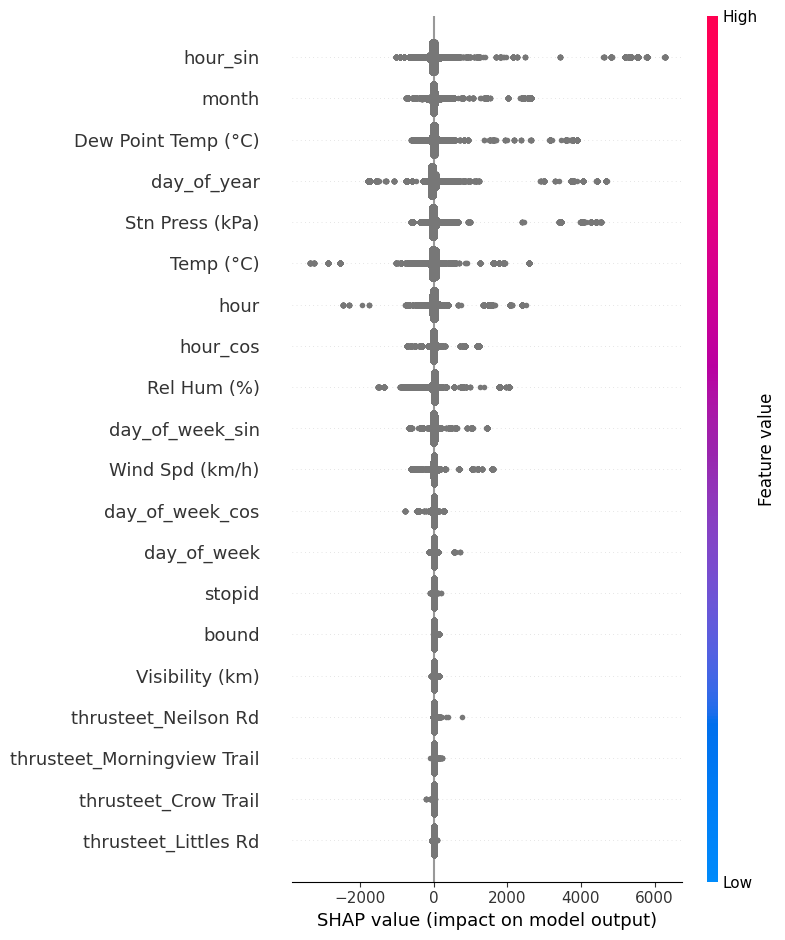

In [69]:
shap.summary_plot(shap_values, X_test_encoded_cupy, feature_names=feature_names)

## Model without categorical data

### Simple Model

In [70]:
cp.get_default_memory_pool().free_all_blocks()

In [71]:
df_without_encoding_X = df_without_encoding.drop(columns=['delay_seconds', 'route', 'trip_id', 'thrusteet', 'actual_arrival', 'nearest_whole_hour'])
df_without_encoding_y = df_without_encoding['delay_seconds']

In [72]:
df_without_encoding_X.head()

,stopid,hour,day_of_week,month,day_of_year,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,Climate ID,Temp (°C),Dew Point Temp (°C),Rel Hum (%),Wind Spd (km/h),Visibility (km),Stn Press (kPa),Precip. Amount (mm),bound
0,8878,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
1,8258,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
2,10060,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
3,938,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0
4,8878,0,2,1,1,0.0,1.0,0.974928,-0.222521,6158731.0,1.6,1.6,100.0,27.0,16.1,97.93,0.5,0


In [73]:
X_train_without_encoding, X_test_without_encoding, y_train_without_encoding, y_test_without_encoding = train_test_split(
    df_without_encoding_X,
    df_without_encoding_y,
    test_size=0.2,
    random_state=42
)

print(f"\nTrain size: {len(X_train_without_encoding):,}")
print(f"Test size: {len(X_test_without_encoding):,}")


Train size: 1,722,566
Test size: 430,642


In [74]:
X_train_without_encoding_cupy = X_train_without_encoding.to_cupy()
y_train_without_encoding_cupy = y_train_without_encoding.to_cupy()
X_test_without_encoding_cupy = X_test_without_encoding.to_cupy()
y_test_without_encoding_cupy = y_test_without_encoding.to_cupy()

In [75]:
# # Define Optuna objective function for hyperparameter tuning
import numpy as np
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,20_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    n_samples = X_train_without_encoding_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    avg_r2_squares = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_without_encoding_cupy[train_index], label=y_train_without_encoding_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_without_encoding_cupy[val_index], label=y_train_without_encoding_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for R2 score calculation
        y_fold = y_train_without_encoding_cupy[val_index].get()
        r2_square = r2_score(y_fold, y_pred)
        avg_r2_squares[i] = r2_square

    # Return average R2 square across folds
    return float(np.mean(avg_r2_squares))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [76]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study
study_simple_without_encoding = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_simple_without_encoding.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_simple_without_encoding.best_trial.number}")
print(f"Best RMSE: {study_simple_without_encoding.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_simple_without_encoding.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 19:34:47,593] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:34:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:34:48,408] Trial 0 finished with value: 0.9277436141767739 and parameters: {'max_depth': 5, 'learning_rate': 0.2536999076681772, 'n_estimators': 18000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746}. Best is trial 0 with value: 0.9277436141767739.


...

[I 2026-03-22 19:35:48,398] Trial 47 finished with value: 0.8810279604155117 and parameters: {'max_depth': 10, 'learning_rate': 0.12687612121792033, 'n_estimators': 11000, 'subsample': 0.8961750562845947, 'colsample_bytree': 0.7633248624903849}. Best is trial 46 with value: 0.9545570088832956.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:35:49,844] Trial 48 finished with value: 0.336468270678332 and parameters: {'max_depth': 10, 'learning_rate': 0.02255700155338065, 'n_estimators': 11000, 'subsample': 0.8566041742914464, 'colsample_bytree': 0.6913386857766859}. Best is trial 46 with value: 0.9545570088832956.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:35:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:35:50,945] Trial 49 finished with value: 0.9498084060354145 and parameters: {'max_depth': 9, 'learning_rate': 0.24752106746253894, 'n_estimators': 10000, 'subsample': 0.886519172016375, 'colsample_bytree': 0.7858927307363938}. Best is trial 46 with value: 0.9545570088832956.

OPTIMIZATION COMPLETE!

Best trial: #46
Best RMSE: 0.9546

Best hyperparameters:
  max_depth: 10
  learning_rate: 0.2966179339596218
  n_estimators: 11000
  subsample: 0.8595849191581006
  colsample_bytree: 0.7687316983567238


In [77]:
fig = optuna.visualization.plot_param_importances(study_simple_without_encoding)
show(fig)

In [78]:
study_simple_without_encoding.best_params

{'max_depth': 10,
 'learning_rate': 0.2966179339596218,
 'n_estimators': 11000,
 'subsample': 0.8595849191581006,
 'colsample_bytree': 0.7687316983567238}

In [79]:
cp.get_default_memory_pool().free_all_blocks()

In [80]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_simple = study_simple_without_encoding.best_params.copy()
best_params_clean = {k: v for k, v in best_params_simple.items() if k != 'num_boost_round'}
best_params_simple['objective'] = 'reg:squarederror'
best_params_simple['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_without_encoding_cupy, y_train_without_encoding_cupy)

# Train final model using native Dask XGBoost
output_simple_without_encoding = xgb.train(
    best_params_simple,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[19:36:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [81]:
dtest = xgb.DMatrix(X_test_without_encoding_cupy)
y_pred_dropped = output_simple_without_encoding.predict(dtest)

In [82]:
rmse_simple_without_encoding = np.sqrt(mean_squared_error(y_test_without_encoding_cupy.get(), y_pred_dropped))
r2_simple_without_encoding = r2_score(y_test_without_encoding_cupy.get(), y_pred_dropped)
mae_simple_without_encoding = mean_absolute_error(y_test_without_encoding_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_simple_without_encoding:.4f}")
print(f"  R²: {r2_simple_without_encoding:.4f}")
print(f"  MAE: {mae_simple_without_encoding:.4f}")

Final Model Performance on Test Set:
  RMSE: 229.1152
  R²: 0.9563
  MAE: 122.4050


In [98]:
# calculate gain feature importance percentages and show in table
import pandas as pd
map_with_features = output_simple_without_encoding.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_without_encoding_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
total_gain = feature_importance_df['Gain'].sum()
feature_importance_df['Gain Percentage'] = (feature_importance_df['Gain'] / total_gain) * 100
print(feature_importance_df)


                Feature          Gain  Gain Percentage
10  Dew Point Temp (°C)  2.310207e+09        26.397362
3                 month  2.050631e+09        23.431339
9             Temp (°C)  1.237129e+09        14.135945
4           day_of_year  1.165085e+09        13.312739
8       day_of_week_cos  7.310161e+08         8.352888
1                  hour  3.602160e+08         4.115974
5              hour_sin  2.754840e+08         3.147793
14      Stn Press (kPa)  2.603200e+08         2.974522
7       day_of_week_sin  2.175330e+08         2.485621
12      Wind Spd (km/h)  4.674124e+07         0.534084
11          Rel Hum (%)  3.940934e+07         0.450307
2           day_of_week  1.921367e+07         0.219543
6              hour_cos  1.513545e+07         0.172944
13      Visibility (km)  1.406094e+07         0.160666
15  Precip. Amount (mm)  4.639955e+06         0.053018
0                stopid  2.626378e+06         0.030010
16                bound  2.209396e+06         0.025245


In [97]:
output_simple_without_encoding.set_param({'device': 'cuda'})

In [85]:
import shap
shap_values = output_simple_without_encoding.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_simple_without_encoding)
shap_values = explainer.shap_values(X_test_without_encoding_cupy)
feature_names = df_without_encoding_X.columns.tolist()

In [86]:
shap_values

array([[ 1.4745688e+01,  3.1371647e+01, -3.2798307e+00, ...,
         1.4112399e+01, -3.2578355e-01, -2.2030182e+00],
       [ 5.4253168e+00,  3.4871788e+01,  5.5886750e+00, ...,
        -2.4713827e+01, -1.8691176e-01, -1.1990069e+00],
       [ 6.0838456e+00, -8.2854340e+01, -3.2539196e+00, ...,
        -9.6873474e+02, -1.0059178e+00, -3.0131325e-01],
       ...,
       [ 1.4841736e+01,  2.7390776e+01, -7.1272955e+00, ...,
        -2.8220545e+01, -2.5350767e-01, -4.4395533e-01],
       [-1.6462873e+01,  9.8070564e+00, -1.9181050e+00, ...,
        -2.0662186e+01, -1.2093596e-01, -1.7266788e+00],
       [-1.1786212e+00, -3.1905052e+01,  1.3004413e+00, ...,
        -2.3038277e+01, -9.0390712e-02, -2.0716345e+00]],
      shape=(430642, 18), dtype=float32)

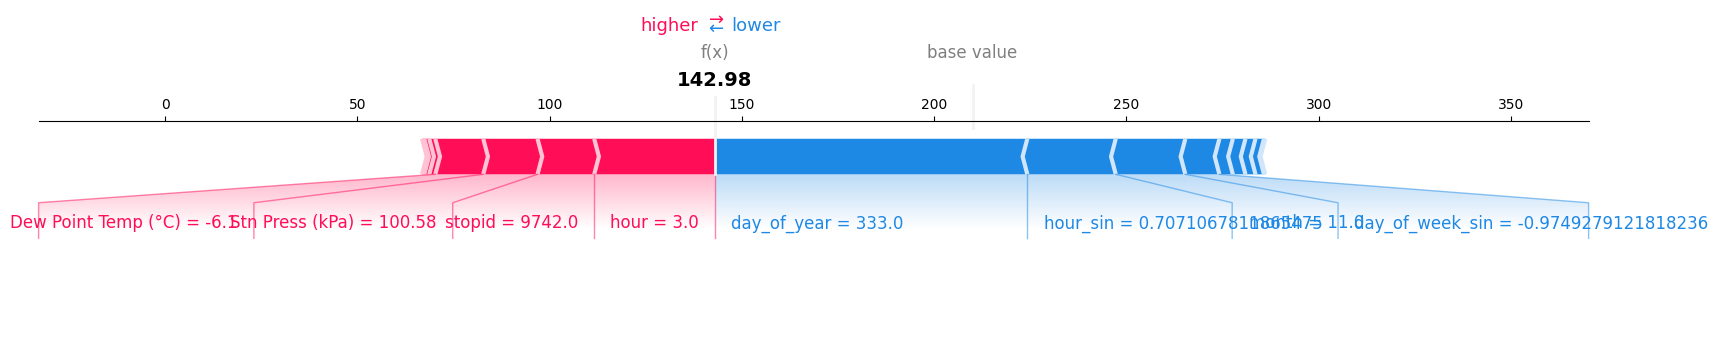

In [87]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_without_encoding_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

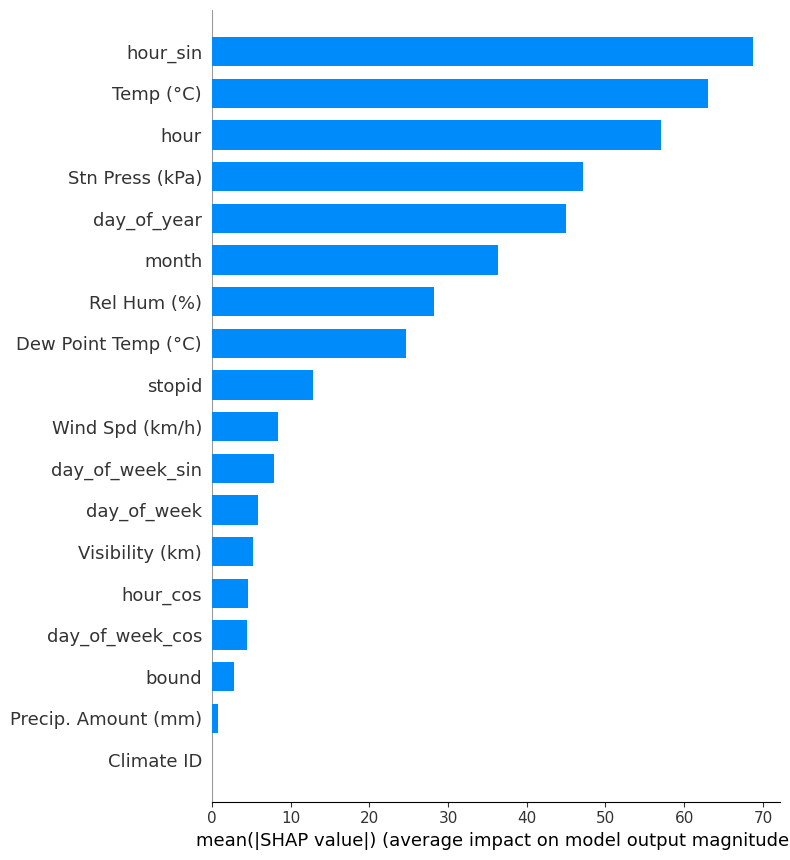

In [88]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, plot_type="bar", feature_names=feature_names)

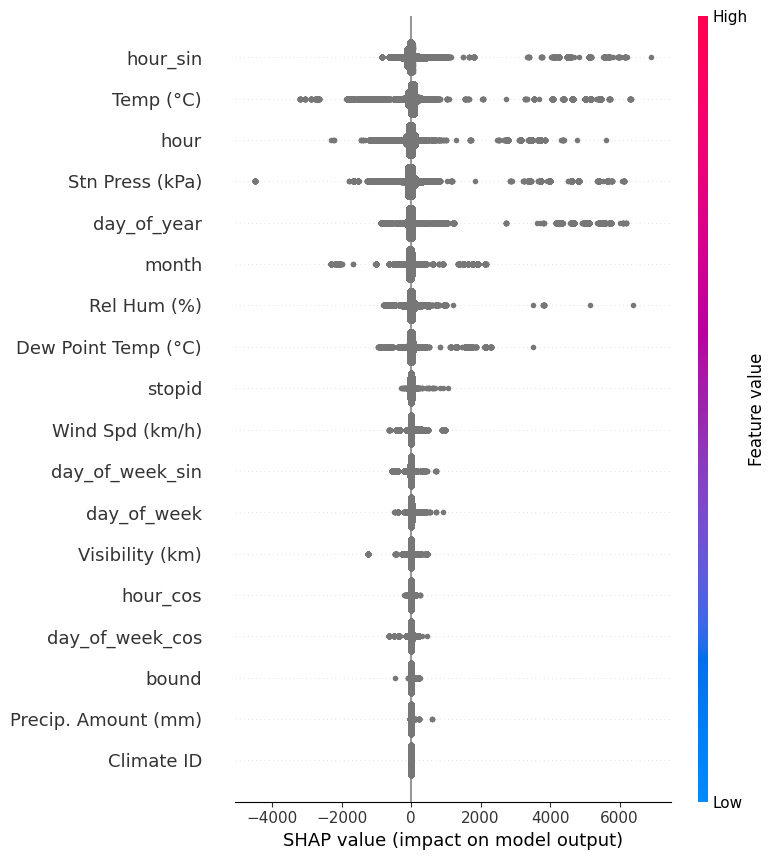

In [89]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, feature_names=feature_names)

### Complex Model

In [92]:
def objective(trial):
    """Optuna objective function to minimize RMSE using native XGBoost Dask API"""
    
    # Define hyperparameter search space
    params = {
        'objective': 'reg:squarederror',
        'tree_method': 'hist',
        'device': 'cuda',
        # Use max_leaves instead of or alongside max_depth for more flexible trees
        'max_leaves': trial.suggest_int('max_leaves', 31, 512),
        'grow_policy': 'lossguide',  # Required for max_leaves to work with hist
        'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 10_000,15_000, step=1000),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        # L2 regularization on leaf weights (default=1)
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),

        # L1 regularization on leaf weights (default=0)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),

        # Minimum loss reduction for further partitioning (default=0)
        'gamma': trial.suggest_float('gamma', 0, 5.0),

        # Minimum child weight — prevents overfitting to small leaf nodes
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'colsample_bylevel': trial.suggest_float('colsample_bylevel', 0.5, 1.0),
        'colsample_bynode': trial.suggest_float('colsample_bynode', 0.5, 1.0),
        
    }
    
    n_samples = X_train_without_encoding_cupy.shape[0]
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
        
    avg_r2_scores = np.zeros(kf.get_n_splits())
    
    # KFold.split only needs sample count — pass a range, no GPU→CPU data transfer
    for i, (train_index, val_index) in enumerate(kf.split(range(n_samples))):
        # Index cupy arrays directly with numpy indices
        dtrain = xgb.QuantileDMatrix(X_train_without_encoding_cupy[train_index], label=y_train_without_encoding_cupy[train_index])
        dval = xgb.QuantileDMatrix(X_train_without_encoding_cupy[val_index], label=y_train_without_encoding_cupy[val_index], ref=dtrain)

        model = xgb.train(params, dtrain, evals=[(dval, 'eval')], 
                      verbose_eval=False, early_stopping_rounds=100)
    
        # Make predictions (returns numpy array)
        y_pred = model.predict(dval)
    
        # Convert only the fold's labels to numpy for RMSE calculation
        y_fold = y_train_without_encoding_cupy[val_index].get()
        r2_scores = r2_score(y_fold, y_pred)
        avg_r2_scores[i] = r2_scores

        trial.report(np.mean(avg_r2_scores), i)
        if trial.should_prune():
            raise optuna.TrialPruned()
        
    # Return average R2 across folds
    return float(np.mean(avg_r2_scores))

print("Objective function defined with native XGBoost and Optuna GPU")

Objective function defined with native XGBoost and Optuna GPU


In [93]:
# Run Optuna hyperparameter optimization
print("Starting Optuna hyperparameter optimization...")
print("XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.")
print("This may take a while...\n")



# Create study with optuna
study_complex_without_encoding = optuna.create_study(
    direction='maximize',  # Maximize R2 square
    study_name='xgboost_delay_prediction',
    sampler=optuna.samplers.TPESampler(seed=42),
)

# Run optimization sequentially (XGBoost Dask handles parallelization internally)
n_trials = 50  # Total number of trials

print(f"Running {n_trials} trials...")

# Run sequential optimization - each trial uses Dask cluster efficiently
study_complex_without_encoding.optimize(objective, n_trials=n_trials, show_progress_bar=True)

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE!")
print("="*60)
print(f"\nBest trial: #{study_complex_without_encoding.best_trial.number}")
print(f"Best RMSE: {study_complex_without_encoding.best_value:.4f}")
print("\nBest hyperparameters:")
for key, value in study_complex_without_encoding.best_params.items():
    print(f"  {key}: {value}")

[I 2026-03-22 19:41:17,571] A new study created in memory with name: xgboost_delay_prediction


Starting Optuna hyperparameter optimization...
XGBoost will use GPU acceleration, and Optuna will run trials sequentially to maximize GPU utilization.
This may take a while...

Running 50 trials...


  0%|          | 0/50 [00:00<?, ?it/s]

/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:41:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:41:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:41:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:41:18] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:41:19,284] Trial 0 finished with value: 0.8824953024210019 and parameters: {'max_leaves': 211, 'learning_rate': 0.24517932047070642, 'n_estimators': 14000, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_lambda': 0.004207053950287938, 'reg_alpha': 0.0017073967431528124, 'gamma': 4.330880728874676, 'min_child_weight': 31, 'colsample_bylevel': 0.8540362888980227, 'colsample_bynode': 0.5102922471479012}. Best is trial 0 with value: 0.8824953024210019.


...

[I 2026-03-22 19:42:11,384] Trial 47 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:42:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




[I 2026-03-22 19:42:11,750] Trial 48 pruned. 


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:42:11] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:42:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:42:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/callback.py:385: UserWarning:

[19:42:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/pyt

[I 2026-03-22 19:42:13,329] Trial 49 finished with value: 0.9398836037092805 and parameters: {'max_leaves': 220, 'learning_rate': 0.2669365514781863, 'n_estimators': 15000, 'subsample': 0.7461916220016103, 'colsample_bytree': 0.980995788576571, 'reg_lambda': 0.0027922151699249368, 'reg_alpha': 0.03301423594984132, 'gamma': 3.9427785619617053, 'min_child_weight': 26, 'colsample_bylevel': 0.7193473953976511, 'colsample_bynode': 0.6887136352891806}. Best is trial 21 with value: 0.9445774541428227.

OPTIMIZATION COMPLETE!

Best trial: #21
Best RMSE: 0.9446

Best hyperparameters:
  max_leaves: 281
  learning_rate: 0.2986174929287041
  n_estimators: 14000
  subsample: 0.8607602327808159
  colsample_bytree: 0.9471397936075646
  reg_lambda: 0.0012345181757780562
  reg_alpha: 0.0031932140997218295
  gamma: 3.3418438760315876
  min_child_weight: 7
  colsample_bylevel: 0.961749692326499
  colsample_bynode: 0.6716536744444684


In [75]:
fig = optuna.visualization.plot_param_importances(study_complex_without_encoding)
show(fig)

In [76]:
study_complex_without_encoding.best_params

{'max_leaves': 281,
 'learning_rate': 0.2986174929287041,
 'n_estimators': 14000,
 'subsample': 0.8607602327808159,
 'colsample_bytree': 0.9471397936075646,
 'reg_lambda': 0.0012345181757780562,
 'reg_alpha': 0.0031932140997218295,
 'gamma': 3.3418438760315876,
 'min_child_weight': 7,
 'colsample_bylevel': 0.961749692326499,
 'colsample_bynode': 0.6716536744444684}

In [77]:
cp.get_default_memory_pool().free_all_blocks()

In [78]:
# Train final model with best parameters using native XGBoost Dask API
print("Training final model with best hyperparameters...")
print("="*60)

# Get best parameters
best_params_complex = study_complex_without_encoding.best_params.copy()
best_params_clean = {k: v for k, v in best_params_complex.items() if k != 'num_boost_round'}
best_params_complex['objective'] = 'reg:squarederror'
best_params_complex['tree_method'] = 'hist'  # Required for Dask

# Create QuantileDMatrix for training
dtrain = xgb.DMatrix(X_train_without_encoding_cupy, y_train_without_encoding_cupy)

# Train final model using native Dask XGBoost
output_complex_without_encoding = xgb.train(
    best_params_complex,
    dtrain,
)

Training final model with best hyperparameters...


/home/artificialstupidity/ttc-bus-delay-prediction/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning:

[15:53:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "n_estimators" } are not used.




In [79]:
dtest = xgb.DMatrix(X_test_without_encoding_cupy)
y_pred_dropped = output_complex_without_encoding.predict(dtest)

In [80]:
rmse_complex_without_encoding = np.sqrt(mean_squared_error(y_test_without_encoding_cupy.get(), y_pred_dropped))
r2_complex_without_encoding = r2_score(y_test_without_encoding_cupy.get(), y_pred_dropped)
mae_complex_without_encoding = mean_absolute_error(y_test_without_encoding_cupy.get(), y_pred_dropped)
print("Final Model Performance on Test Set:")
print(f"  RMSE: {rmse_complex_without_encoding:.4f}")
print(f"  R²: {r2_complex_without_encoding:.4f}")
print(f"  MAE: {mae_complex_without_encoding:.4f}")

Final Model Performance on Test Set:
  RMSE: 268.4085
  R²: 0.9401
  MAE: 131.5913


In [ ]:
import pandas as pd
map_with_features = output_complex_without_encoding.get_score(importance_type='gain')
feature_importance_df = pd.DataFrame(map_with_features.items(), columns=['Feature', 'Gain'])
feature_importance_df['Feature'] = feature_importance_df['Feature'].apply(lambda x: df_without_encoding_X.columns[int(x[1:])])
feature_importance_df = feature_importance_df.sort_values(by='Gain', ascending=False)
print(feature_importance_df)

In [81]:
output_complex_without_encoding.set_param({'device': 'cuda'})

In [82]:
shap_values = output_complex_without_encoding.predict(dtest, pred_contribs=True)
explainer = shap.TreeExplainer(output_complex_without_encoding)
shap_values = explainer.shap_values(X_test_without_encoding_cupy)
feature_names = df_without_encoding_X.columns.tolist()

In [83]:
shap_values

array([[ 3.8356214e+00, -6.2490463e+00, -2.1004524e+00, ...,
         2.0212379e+01, -3.7746340e-01, -1.2521766e+00],
       [-4.3364420e+00,  2.8518745e+01, -4.4269417e+01, ...,
         5.4345852e+01, -2.5147449e-02, -7.6038188e-01],
       [ 3.1030424e+01,  3.2699356e+01,  7.6192212e-01, ...,
        -6.9884766e+02, -1.9421093e-02, -5.8750623e-01],
       ...,
       [ 6.6449394e+00,  1.8530310e+01, -4.8999124e+00, ...,
        -1.2161193e+01, -4.8872575e-02, -1.0824994e+00],
       [-3.2620506e+00, -9.4140491e+00,  9.5390087e-01, ...,
        -1.2810784e+01, -4.8405014e-02, -1.4788048e+00],
       [-6.7883067e-02, -8.0994301e+00,  1.1542211e+01, ...,
         5.1120136e+01, -4.6123341e-02, -1.4012961e+00]],
      shape=(430642, 18), dtype=float32)

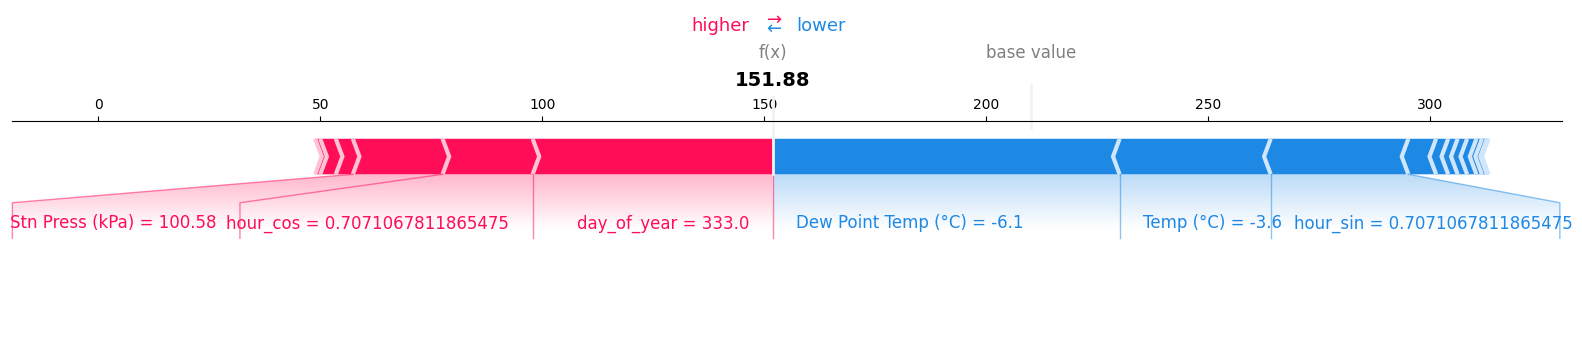

In [84]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0, :],
    X_test_without_encoding_cupy[0, :].get(),
    feature_names=feature_names,
    matplotlib=True,
)

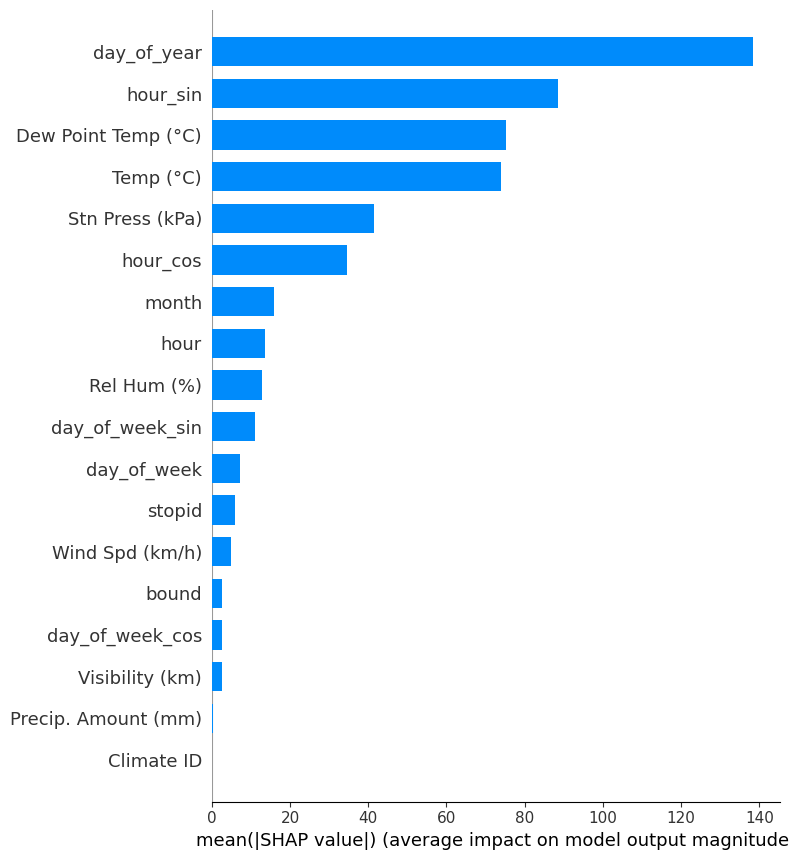

In [85]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, plot_type="bar", feature_names=feature_names)

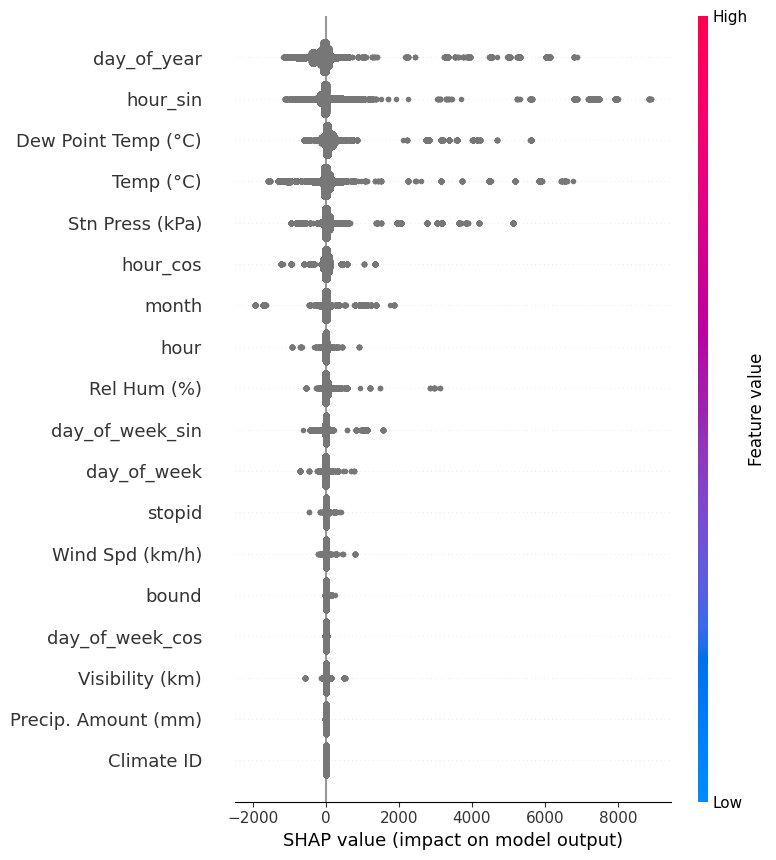

In [86]:
shap.summary_plot(shap_values, X_test_without_encoding_cupy, feature_names=feature_names)

## Model Comparison

In [87]:
# now we make chart of complex vs simple, rmse and r2 in two figure using plotly
from plotly.subplots import make_subplots
import plotly.graph_objects as go

rmse = [rmse_simple_without_encoding, rmse_complex_without_encoding, rmse_simple_encoded, rmse_complex_encoded]
r2 = [r2_simple_without_encoding, r2_complex_without_encoding, r2_simple_encoded, r2_complex_encoded]
mae = [mae_simple_without_encoding, mae_complex_without_encoding, mae_simple_encoded, mae_complex_encoded]
models = ['Simple Model', 'Complex Model', 'Simple Model (Encoded)', 'Complex Model (Encoded)']

# using 1,2 subplot
fig = make_subplots(rows=1, cols=3, subplot_titles=('RMSE', 'R²', 'MAE'))
fig.add_trace(go.Bar(x=models, y=rmse), row=1, col=1)
fig.add_trace(go.Bar(x=models, y=r2), row=1, col=2)
fig.add_trace(go.Bar(x=models, y=mae), row=1, col=3)
fig.update_layout(title_text='Model Performance Comparison', showlegend=False)
fig.update_xaxes(title_text='Model', row=1, col=1)
fig.update_xaxes(title_text='Model', row=1, col=2)
fig.update_yaxes(title_text='RMSE', row=1, col=1)
fig.update_yaxes(title_text='R²', row=1, col=2)
fig.update_yaxes(title_text='MAE', row=1, col=3)

fig.show()